In [74]:
import scanpy as sc 
import numpy as np 
from sklearn.model_selection import StratifiedShuffleSplit, ShuffleSplit, train_test_split 
from sklearn.preprocessing import LabelEncoder 
import pandas as pd 
import matplotlib.pyplot as plt

In [75]:
def load_adata(file_path):
    adata = sc.read_h5ad(file_path)
    return adata 

In [76]:
project_path=".."

In [77]:
ls ../data/raw/COVID_Haniffa21/

cohort_data.h5ad   cohort_node2.h5ad           haniffa21.processed.h5ad
cohort_node1.h5ad  haniffa21.max_patient.h5ad  preprocessing_covid.ipynb


In [78]:
anndata = load_adata(f"{project_path}/data/raw/COVID_Haniffa21/cohort_node2.h5ad")

In [79]:
tag='COVID_Haniffa21-swarm-node2'

In [80]:
anndata

AnnData object with n_obs × n_vars = 345580 × 24737
    obs: 'sample_id', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'full_clustering', 'initial_clustering', 'Resample', 'Collection_Day', 'Sex', 'Age_interval', 'Swab_result', 'Status', 'Smoker', 'Status_on_day_collection', 'Status_on_day_collection_summary', 'Days_from_onset', 'Site', 'time_after_LPS', 'Worst_Clinical_Status', 'Outcome', 'patient_id', 'disease_label'
    layers: 'raw'

In [81]:
anndata.obs['Status'].value_counts()

Covid      292906
Healthy     52674
Name: Status, dtype: int64

In [82]:
anndata.X.max(), anndata.X.min() 

(47487.0, 0.0)

#### Preprocessing - GroundGAN style

(array([10.,  8.,  3.,  6.,  8.,  8.,  7.,  1.,  2.,  2.]),
 array([ 1184. ,  2497.3,  3810.6,  5123.9,  6437.2,  7750.5,  9063.8,
        10377.1, 11690.4, 13003.7, 14317. ]),
 <BarContainer object of 10 artists>)

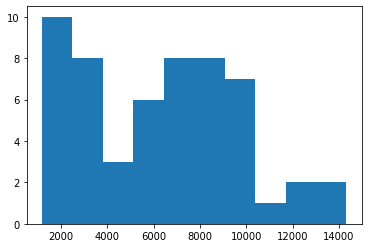

In [83]:
plt.hist(anndata.obs.groupby('patient_id', observed=True)['patient_id'].size())

In [84]:
random_state=1000
import random
random.seed(random_state) 

In [85]:
# disease_class = 'covid' if disease_label == 0 else 'healthy'
# project_dir="/home/c01teaf/CISPA-az6/llm_tg-2024/GRouNdGAN"
# data_path = f"{project_dir}/data/processed/COVID_Haniffa21-GGpp-{disease_class}/CrossVal_{random_state}/"
# print(data_path)

In [86]:
n_top_genes = 1000 # int(cfg.get("Preprocessing", "highly variable number"))
resolution = 0.15 # cfg.get("Preprocessing", "louvain res")
min_genes = 200 # int(cfg.get("Preprocessing", "min genes"))
min_cells = 3 # int(cfg.get("Preprocessing", "min cells"))
counts_per_cell_after = 20000 #int(cfg.get("Preprocessing", "library size"))
val_size = 1000 # int(cfg.get("Preprocessing", "validation set size"))
test_size = 1000 # int(cfg.get("Preprocessing", "test set size"))
# path_to_train = f"{data_path}/train.h5ad" # cfg.get("Data", "train")
# path_to_validation = f"{data_path}/validation.h5ad" # cfg.get("Data", "validation")
# path_to_test = f"{data_path}/test.h5ad" # cfg.get("Data", "test")

In [87]:
test_size = int((anndata.obs.groupby('patient_id', observed=True)['patient_id'].size()*0.1).sum())
test_size

34558

In [88]:
original_order = np.arange(anndata.n_obs)  # Store the original cell order
np.random.shuffle(original_order)  # Shuffle the indices

# Apply the shuffled order to the AnnData object
anndata = anndata[original_order]

In [89]:
# clustering
ann_clustered = anndata.copy()
sc.pp.recipe_zheng17(ann_clustered,  n_top_genes=n_top_genes)
sc.tl.pca(ann_clustered, n_comps=50)
sc.pp.neighbors(ann_clustered, n_pcs=50)
sc.tl.louvain(ann_clustered, resolution=resolution)
anndata.obs["cluster"] = ann_clustered.obs["louvain"]

Trying to set attribute `.obs` of view, copying.


In [90]:
anndata.obs['initial_clustering'].unique()

['NK_16hi', 'CD14', 'B_cell', 'CD8', 'CD16', ..., 'HSC', 'gdT', 'Lymph_prolif', 'pDC', 'Treg']
Length: 18
Categories (18, object): ['B_cell', 'CD4', 'CD8', 'CD14', ..., 'RBC', 'Treg', 'gdT', 'pDC']

In [91]:
from collections import Counter

# get cluster ratios
cells_per_cluster = Counter(anndata.obs["cluster"])
cluster_ratios = dict()
for key, value in cells_per_cluster.items():
    cluster_ratios[key] = value / anndata.shape[0]
anndata.uns["cluster_ratios"] = cluster_ratios
anndata.uns["clusters_no"] = len(cluster_ratios)

In [92]:
# filtering
sc.pp.filter_cells(anndata, min_genes=min_genes)
sc.pp.filter_genes(anndata, min_cells=min_cells)
anndata.uns["cells_no"] = anndata.shape[0]
anndata.uns["genes_no"] = anndata.shape[1]

In [93]:
canndata = anndata.copy()

In [94]:
# library-size normalization
sc.pp.normalize_per_cell(canndata, counts_per_cell_after=counts_per_cell_after)

In [95]:
# identify highly variable genes
from scipy.sparse import issparse


sc.pp.log1p(canndata)  # logarithmize the data
sc.pp.highly_variable_genes(canndata, n_top_genes=n_top_genes)

if issparse(canndata.X):
    canndata.X = np.exp(canndata.X.toarray()) - 1  # get back original data
else:
    canndata.X = np.exp(canndata.X) - 1  # get back original data

anndata = anndata[
    :, canndata.var["highly_variable"]
]  # only keep highly variable genes

sc.pp.normalize_per_cell(anndata, counts_per_cell_after=counts_per_cell_after)

Trying to set attribute `.obs` of view, copying.


In [96]:
# sort genes by name (not needed)
sorted_genes = np.sort(anndata.var_names)
anndata = anndata[:, sorted_genes]

In [97]:
from sklearn.model_selection import train_test_split
import numpy as np

def split_data(anndata, label_column):
    y = anndata.obs[label_column].values
    X_idx = np.arange(anndata.n_obs)
    X_train, X_temp, y_train, y_temp = train_test_split(
                                        X_idx, 
                                        y, 
                                        test_size=test_size+val_size,
                                        random_state=random_state,
                                        stratify=y
                                    )
    X_val, X_test, y_val, y_test = train_test_split(
                                    X_temp, 
                                    y_temp,
                                    test_size=test_size,
                                    random_state=random_state,
                                    stratify=y_temp
                                )
    anndata_train = anndata[X_train].copy()
    anndata_val = anndata[X_val].copy()
    anndata_test = anndata[X_test].copy()
    return anndata_train, anndata_val, anndata_test

In [98]:
stratified_sampling = True

In [99]:
if stratified_sampling:
    label_column='Status'
    anndata_train, anndata_val, anndata_test = split_data(anndata, label_column)
else:
    anndata_val = anndata[:val_size]
    anndata_test = anndata[val_size : test_size + val_size]
    anndata_train = anndata[test_size + val_size :]

In [100]:
anndata_train_covid = anndata_train[anndata_train.obs.Status == "Covid"]
anndata_train_healthy = anndata_train[anndata_train.obs.Status == "Healthy"]

anndata_test_covid = anndata_test[anndata_test.obs.Status == "Covid"]
anndata_test_healthy = anndata_test[anndata_test.obs.Status == "Healthy"]


anndata_val_covid = anndata_val[anndata_val.obs.Status == "Covid"]
anndata_val_healthy = anndata_val[anndata_val.obs.Status == "Healthy"]

In [101]:
for split in [anndata_train, anndata_val, anndata_test]:
    print(split.obs[label_column].value_counts(normalize=True))
    print("---")

Covid      0.847572
Healthy    0.152428
Name: Status, dtype: float64
---
Covid      0.848
Healthy    0.152
Name: Status, dtype: float64
---
Covid      0.847561
Healthy    0.152439
Name: Status, dtype: float64
---


In [102]:
for split in [anndata_train_covid, anndata_val_covid, anndata_test_covid]:
    print(len(split.obs['patient_id'].unique()))
    print("---")

44
---
43
---
44
---


In [103]:
for split in [anndata_train_healthy, anndata_val_healthy, anndata_test_healthy]:
    print(len(split.obs['patient_id'].unique()))
    print("---")

11
---
11
---
11
---


In [104]:
for split in [anndata_train, anndata_val, anndata_test]:
    print(len(split.obs['initial_clustering'].unique()))
    print(split.obs['initial_clustering'].value_counts())
    print("---")

18
CD14            62635
CD4             59775
CD8             49873
NK_16hi         44482
B_cell          34716
CD16             9753
Platelets        8028
Plasmablast      6529
gdT              6379
NK_56hi          5652
Treg             5350
Lymph_prolif     3748
DCs              3598
MAIT             3248
pDC              2761
HSC              1558
RBC              1412
Mono_prolif       499
Name: initial_clustering, dtype: int64
---
18
CD14            209
CD4             201
CD8             177
NK_16hi         128
B_cell          108
gdT              28
NK_56hi          24
Plasmablast      22
Platelets        21
CD16             20
Treg             19
pDC              10
Lymph_prolif     10
DCs               7
MAIT              6
HSC               5
Mono_prolif       3
RBC               2
Name: initial_clustering, dtype: int64
---
18
CD14            6884
CD4             6643
CD8             5655
NK_16hi         4966
B_cell          3915
CD16            1140
Platelets        895
gd

In [105]:
for split in [anndata_train_covid, anndata_val_covid, anndata_test_covid]:
    print(len(split.obs['initial_clustering'].unique()))
    print(split.obs['initial_clustering'].value_counts())
    print("---")

18
CD14            56898
CD4             48019
CD8             40588
NK_16hi         38552
B_cell          30050
CD16             7770
Platelets        7261
Plasmablast      6479
NK_56hi          4755
Treg             4347
gdT              3960
Lymph_prolif     3595
DCs              2440
pDC              2370
MAIT             2350
HSC              1495
RBC              1319
Mono_prolif       496
Name: initial_clustering, dtype: int64
---
18
CD14            188
CD4             164
CD8             154
NK_16hi         110
B_cell           95
NK_56hi          21
Plasmablast      21
Platelets        18
CD16             16
gdT              15
Treg             15
Lymph_prolif     10
DCs               6
pDC               4
HSC               4
MAIT              3
Mono_prolif       3
RBC               1
Name: initial_clustering, dtype: int64
---
18
CD14            6280
CD4             5346
CD8             4583
NK_16hi         4326
B_cell          3375
CD16             916
Platelets        815
Pl

In [106]:
for split in [anndata_train_healthy, anndata_val_healthy, anndata_test_healthy]:
    print(len(split.obs['initial_clustering'].unique()))
    print(split.obs['initial_clustering'].value_counts())
    print("---")

18
CD4             11756
CD8              9285
NK_16hi          5930
CD14             5737
B_cell           4666
gdT              2419
CD16             1983
DCs              1158
Treg             1003
MAIT              898
NK_56hi           897
Platelets         767
pDC               391
Lymph_prolif      153
RBC                93
HSC                63
Plasmablast        50
Mono_prolif         3
Name: initial_clustering, dtype: int64
---
16
CD4            37
CD8            23
CD14           21
NK_16hi        18
B_cell         13
gdT            13
pDC             6
CD16            4
Treg            4
MAIT            3
NK_56hi         3
Platelets       3
DCs             1
HSC             1
Plasmablast     1
RBC             1
Name: initial_clustering, dtype: int64
---
17
CD4             1297
CD8             1072
NK_16hi          640
CD14             604
B_cell           540
gdT              273
CD16             224
NK_56hi          117
DCs              115
MAIT             111
Treg       

In [107]:
import os

In [108]:
os.makedirs(f"{project_path}/data/processed/{tag}-covid/CrossVal_{random_state}", exist_ok=True)

anndata_train_covid.write_h5ad(f"{project_path}/data/processed/{tag}-covid/CrossVal_{random_state}/train.h5ad")
anndata_val_covid.write_h5ad(f"{project_path}/data/processed/{tag}-covid/CrossVal_{random_state}/validation.h5ad")
anndata_test_covid.write_h5ad(f"{project_path}/data/processed/{tag}-covid/CrossVal_{random_state}/test.h5ad")
    
####
print("Successfully preprocessed and and saved dataset")

Successfully preprocessed and and saved dataset


In [109]:
os.makedirs(f"{project_path}/data/processed/{tag}-healthy/CrossVal_{random_state}", exist_ok=True)
anndata_train_healthy.write_h5ad(f"{project_path}/data/processed/{tag}-healthy/CrossVal_{random_state}/train.h5ad")
anndata_val_healthy.write_h5ad(f"{project_path}/data/processed/{tag}-healthy/CrossVal_{random_state}/validation.h5ad")
anndata_test_healthy.write_h5ad(f"{project_path}/data/processed/{tag}-healthy/CrossVal_{random_state}/test.h5ad")
    
####
print("Successfully preprocessed and and saved dataset")

Successfully preprocessed and and saved dataset
